## Part A: Data Preprocessing and Imputation

### Load and Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import classification_report, accuracy_score, f1_score, precision_score, recall_score

In [2]:
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14

In [3]:
# Load data
df = pd.read_csv(r"UCI_Credit_Card.csv")
print("Initial shape:", df.shape)

Initial shape: (30000, 25)


In [4]:
# Print first 5 rows
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [5]:
target = "default.payment.next.month"

# Introduce Missing at Random (MAR) in 10% of values in 3 numeric cols
rng = np.random.RandomState(0)
cols_to_miss = ["AGE", "BILL_AMT1", "BILL_AMT2"]

for col in cols_to_miss:
    missing_indices = rng.choice(df.index, size=int(0.1 * len(df)), replace=False)
    df.loc[missing_indices, col] = np.nan

In [6]:
# Check missing percentages
print("Missing Value Percentage:")
print(df[cols_to_miss].isna().mean().round(3))

Missing Value Percentage:
AGE          0.1
BILL_AMT1    0.1
BILL_AMT2    0.1
dtype: float64


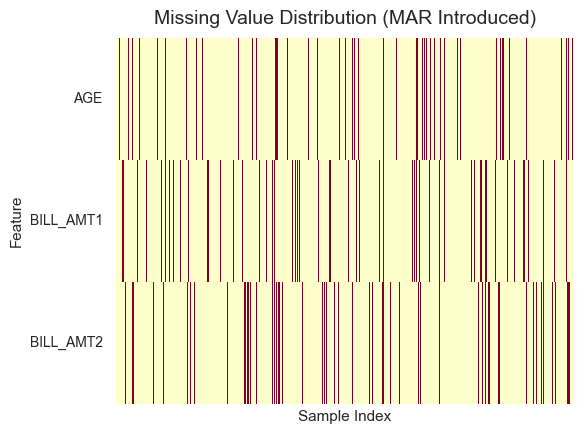

In [7]:
# Heatmap
plt.figure(figsize=(6, 1.5 * len(cols_to_miss)))
sns.heatmap(
    df[cols_to_miss].isna().T,
    cmap="YlOrRd",
    cbar=False,
    linecolor="white"
)

plt.title("Missing Value Distribution (MAR Introduced)", fontsize=14, pad=10)
plt.xlabel("Sample Index", fontsize=11)
plt.ylabel("Feature", fontsize=11)
plt.yticks(rotation=0, fontsize=10)
plt.xticks([], [])  # hide crowded x-axis ticks
plt.tight_layout()
plt.show()

### Imputation Strategy 1: Simple Imputation (Baseline)

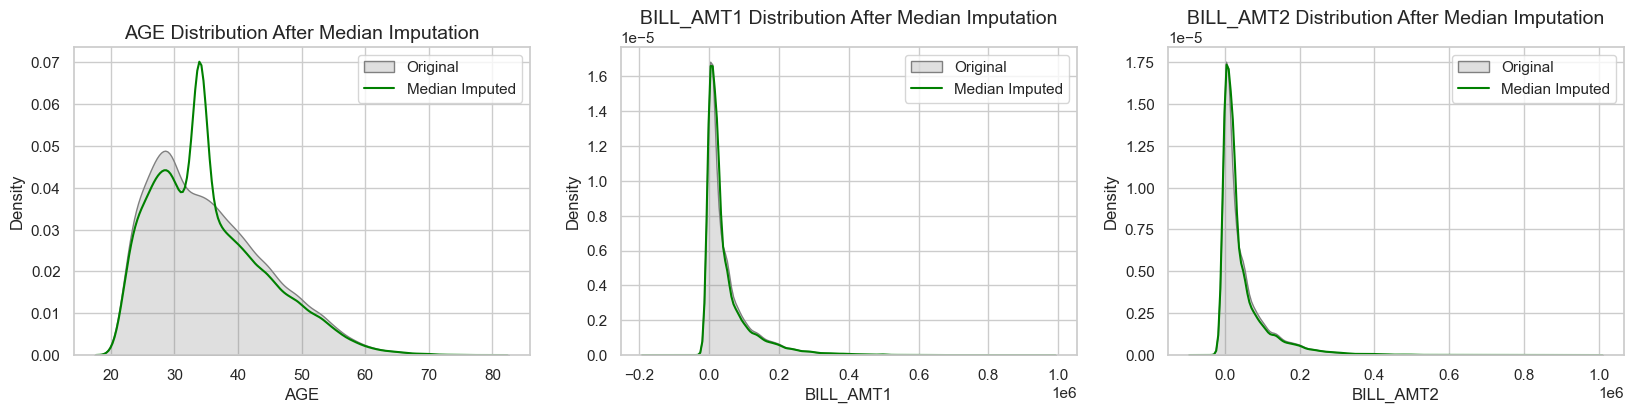

In [8]:
A = df.copy()
for col in cols_to_miss:
    A[col] = A[col].fillna(A[col].median())

# Visual Comparison
fig, axes = plt.subplots(1, 3, figsize=(20,4))
for i, col in enumerate(cols_to_miss):
    sns.kdeplot(df[col], label="Original", ax=axes[i], color='gray', fill=True)
    sns.kdeplot(A[col], label="Median Imputed", ax=axes[i], color='green')
    axes[i].set_title(f"{col} Distribution After Median Imputation")
    axes[i].legend()
plt.show()

#### Why Median is Often Better than Mean for Imputation

When handling missing values in a dataset, **imputation** replaces missing entries with a representative value. Two common choices for numeric data are **mean** and **median**.  

---

**1. Definitions**

- **Mean**: Arithmetic average of all values.
$\text{mean} = \dfrac{1}{n} \sum_{i=1}^{n} x_i$

- **Median**: Middle value when all values are sorted.  

For an odd number of elements:
$\text{median} = x_{\frac{n+1}{2}}$

For an even number of elements:
$\text{median} = \dfrac{x_{\frac{n}{2}} + x_{\frac{n}{2}+1}}{2}$

---

**2. Sensitivity to Outliers**

The **mean** is sensitive to extreme values (outliers).  

Example dataset:
$X = [10, 12, 14, 15, 1000]$

- Mean:  
$\dfrac{10 + 12 + 14 + 15 + 1000}{5} = 210.2$

- Median:  
$14 \quad (\text{middle value})$

> The mean is skewed by the outlier `1000`, while the median remains representative.

---

**3. Robustness**

Mathematically:

- **Median** minimizes the sum of absolute deviations:
$\text{median} = \arg \min_m \sum_{i=1}^n |x_i - m|$

- **Mean** minimizes the sum of squared deviations:
$\text{mean} = \arg \min_\mu \sum_{i=1}^n (x_i - \mu)^2$

Squared deviations exaggerate large differences, making the mean sensitive to outliers. Absolute deviations give equal weight, making the median robust.

---

**4. Practical Implication**

- **Mean imputation** can distort the dataset in presence of outliers.  
- **Median imputation** preserves the central tendency and reduces skewing.  

**Conclusion:**  
> For skewed distributions or datasets with outliers, **median imputation** is preferred because it is robust, less sensitive to extremes, and better preserves the underlying distribution.


### Imputation Strategy 2: Linear Regression Imputation

In [9]:
B = df.copy()
target_col = 'AGE' 

B_temp = B.fillna(B.median(numeric_only=True))

known = B[B[target_col].notnull()]
missing = B[B[target_col].isnull()]

X_train = B_temp.loc[known.index].drop(columns=[target_col, target])
y_train = known[target_col]
X_pred = B_temp.loc[missing.index].drop(columns=[target_col, target])

linreg = LinearRegression()
linreg.fit(X_train, y_train)

preds_linear = linreg.predict(X_pred)
B.loc[missing.index, target_col] = preds_linear
B = B.fillna(B.median(numeric_only=True))

#### Imputing a Single Column Using Linear Regression: Assumptions

When we impute missing values in a target column using **linear regression** based on other features, we rely on several underlying assumptions. These assumptions ensure that the regression predictions are meaningful and that the imputed values are reasonable.

---

**1. Linearity**

We assume that the **target column** $Y$ has a linear relationship with the predictor columns $X_1, X_2, \dots, X_p$:

$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_p X_p + \epsilon$

- $\beta_i$ are regression coefficients.  
- $\epsilon$ is the error term (residual).  

> The better the linearity, the more accurate the imputed values.

---

**2. Independence of Errors**

The residuals $\epsilon_i$ are assumed to be **independent**:

$\text{Cov}(\epsilon_i, \epsilon_j) = 0 \quad \forall i \neq j$

- This means that knowing one residual does not give information about another.  
- Violations can occur in time series or grouped data.

---

**3. Homoscedasticity**

The variance of the residuals is assumed to be constant across all levels of predictors:

$\text{Var}(\epsilon_i) = \sigma^2 \quad \forall i$

- If variance changes (heteroscedasticity), the predicted values may be biased or less reliable.

---

**4. No Perfect Multicollinearity**

The predictor variables $X_1, X_2, \dots, X_p$ should **not be perfectly correlated**:

$\text{No exact linear relationship among predictors}$

- Perfect multicollinearity makes the estimation of $\beta_i$ impossible.  
- For imputation, correlated columns are okay but should avoid exact duplicates.

---

**5. Normality of Errors**

For inference and confidence intervals, residuals are ideally **normally distributed**:

$\epsilon_i \sim \mathcal{N}(0, \sigma^2)$

- For simple imputation, normality is less critical.  
- Helps in assessing prediction uncertainty.

---

**6. Practical Implications for Imputation**

- **Predictive Power:** The target column should be predictable from other features.  
- **Robustness:** Outliers in predictors or target can distort imputation.  
- **Data Consistency:** Linear regression imputes continuous values; categorical columns require encoding or different methods.

> **Conclusion:**  
> Imputing a column with linear regression assumes that the missing values can be approximated as a linear function of other columns, errors are reasonably well-behaved, and predictor variables are not perfectly redundant.


### Imputation Strategy 3: Non-Linear Regression Imputation

In [10]:
C = df.copy()
target_col = 'AGE' 

C_temp = C.fillna(C.median(numeric_only=True))

known = C[C[target_col].notnull()]
missing = C[C[target_col].isnull()]

X_train = C_temp.loc[known.index].drop(columns=[target_col, target])
y_train = known[target_col]
X_pred = C_temp.loc[missing.index].drop(columns=[target_col, target])

knnreg = KNeighborsRegressor(n_neighbors=5)
knnreg.fit(X_train, y_train)

preds_knn = knnreg.predict(X_pred)
C.loc[missing.index, target_col] = preds_knn
C = C.fillna(C.median(numeric_only=True))

#### Choosing KNN Regressor for Non-linear Imputation

When imputing missing values in a target column using other features, **non-linear relationships** between columns can make linear models insufficient. Two common choices for non-linear imputation are **K-Nearest Neighbors (KNN) Regressor** and **Decision Tree Regressor**. Here’s why KNN was chosen:

---

**1. Local vs. Global Prediction**

- **KNN Regressor** predicts a missing value based on the **average of its k nearest neighbors** in feature space:

$\hat{y} = \frac{1}{k} \sum_{i \in \text{neighbors}} y_i$

- **Decision Tree Regressor** splits the feature space into regions and assigns a constant value to each leaf.  

> KNN captures **local patterns**, while decision trees approximate piecewise constant functions. For smooth non-linear relationships, KNN often produces more realistic imputations.

---

**2. Smoothness of Imputed Values**

- KNN produces **continuous, smooth estimates** as it averages over neighbors.  
- Decision Trees produce **step-like jumps** because each leaf predicts a constant value.  

> For numeric columns where smooth variation is expected, KNN provides more natural imputations.

---

**3. Sensitivity to Noise and Overfitting**

- Decision Trees can **overfit small datasets**, predicting extreme or unrealistic values in leaves with few samples.  
- KNN naturally **averages across neighbors**, reducing the impact of noise in predictors.  

---

**4. Assumptions**

- **KNN** assumes that similar rows have similar target values (**local similarity principle**).  
- **Decision Trees** assume the feature space can be **split hierarchically** to capture patterns.  
- For imputation, local similarity is often more intuitive, especially when the relationship is complex and smooth.

---

**5. Practical Implications**

- KNN is well-suited for **continuous, non-linear relationships** where smooth predictions are preferred.  
- Decision Trees are more suitable for **categorical-like splits or highly irregular patterns**.  

> **Conclusion:**  
> Choosing **KNN Regressor** for non-linear imputation provides smoother, locally-informed predictions, reduces overfitting, and better preserves the underlying data structure compared to a Decision Tree Regressor.


### Imputation Strategy 4: Listwise Deletion

In [11]:
D = df.dropna()

## Part B: Model Training and Performance Assessment

In [12]:
def train_and_report(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression(max_iter=1000, solver="newton-cholesky")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    report = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    }

    print(f"\n{label} Results:")
    print(classification_report(y_test, y_pred, digits=3))
    return report

y = df[target]
y_D = y.loc[D.index]

results = {}
results["A"] = train_and_report(A.drop(columns=[target]), y, "Median Imputation")
results["B"] = train_and_report(B.drop(columns=[target]), y, "Linear Regression Imputation")
results["C"] = train_and_report(C.drop(columns=[target]), y, "Non-Linear (KNN) Imputation")
results["D"] = train_and_report(D.drop(columns=[target]), y_D, "Listwise Deletion")


Median Imputation Results:
              precision    recall  f1-score   support

           0      0.822     0.979     0.894      4703
           1      0.756     0.234     0.357      1297

    accuracy                          0.818      6000
   macro avg      0.789     0.606     0.625      6000
weighted avg      0.808     0.818     0.778      6000


Linear Regression Imputation Results:
              precision    recall  f1-score   support

           0      0.823     0.979     0.894      4703
           1      0.759     0.235     0.359      1297

    accuracy                          0.819      6000
   macro avg      0.791     0.607     0.627      6000
weighted avg      0.809     0.819     0.779      6000


Non-Linear (KNN) Imputation Results:
              precision    recall  f1-score   support

           0      0.823     0.979     0.894      4703
           1      0.757     0.236     0.360      1297

    accuracy                          0.819      6000
   macro avg      0.790

## Part C: Comparative Analysis

### Results Comparison

,Accuracy,Precision,Recall,F1-score
D,0.812,0.734,0.255,0.378
C,0.818,0.757,0.236,0.360
B,0.818,0.759,0.235,0.359
A,0.818,0.756,0.234,0.357


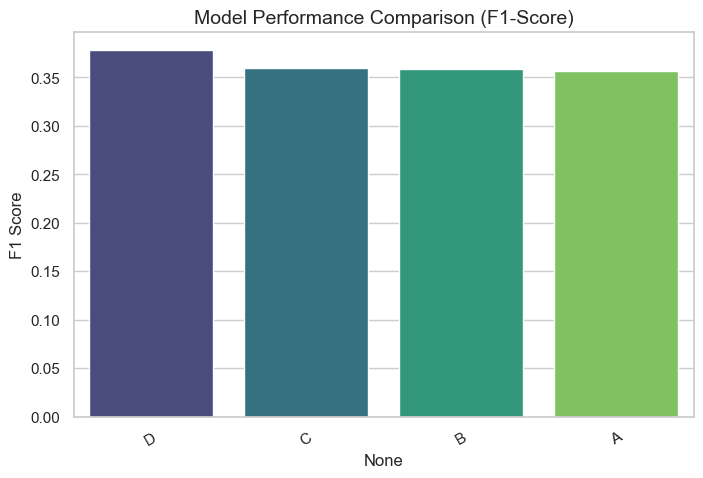

In [13]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="F1-score", ascending=False)
display(results_df.round(3))

plt.figure(figsize=(8,5))
sns.barplot(x=results_df.index, y="F1-score", data=results_df, palette="viridis", hue=results_df.index, legend=False)
plt.title("Model Performance Comparison (F1-Score)")
plt.xticks(rotation=30)
plt.ylabel("F1 Score")
plt.show()

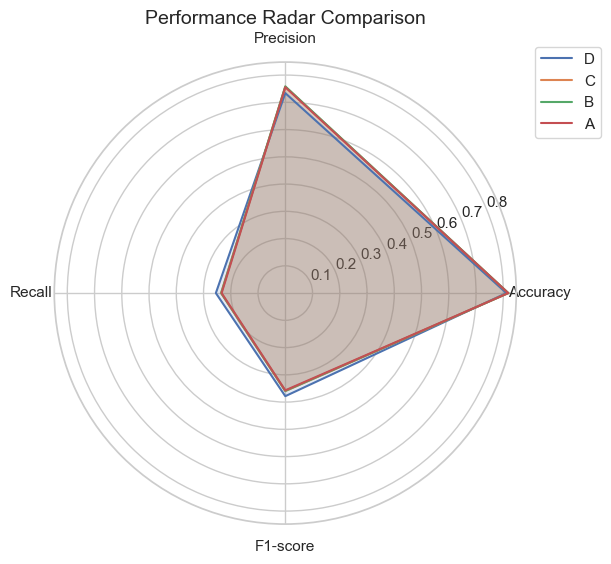

In [14]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
labels = results_df.index.tolist()
num_vars = len(metrics)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

for label in labels:
    values = results_df.loc[label].tolist()
    values += values[:1]
    ax.plot(angles, values, label=label)
    ax.fill(angles, values, alpha=0.15)

ax.set_thetagrids(np.degrees(angles[:-1]), metrics)
plt.title("Performance Radar Comparison")
plt.legend(bbox_to_anchor=(1.2, 1.05))
plt.show()

### Efficacy Discussion

**Analysis of Data Imputation and Listwise Deletion Strategies**

The experiment compares four strategies for handling missing data on the UCI Credit Card Default Clients Dataset: **D (Listwise Deletion)**, **A (Median Imputation)**, **B (Linear Regression Imputation)**, and **C (KNN Regressor Imputation)**. The performance is assessed using **Accuracy, Precision, Recall, and F1-score**.

***

**1. Trade-Offs: Listwise Deletion (D) vs. Imputation (A, B, C)**

The primary trade-off is between **sample size/representativeness** (Imputation's strength) and **data purity/imputation bias** (Deletion's strength).

| Metric | D (Listwise Deletion) | A (Median) | B (Linear Reg) | C (KNN Reg) |
| :---: | :---: | :---: | :---: | :---: |
| **Accuracy** | $0.812$ | $0.818$ | $0.818$ | $0.818$ |
| **Precision** | $0.734$ | $0.756$ | $0.759$ | $0.757$ |
| **Recall** | $0.255$ | $0.234$ | $0.235$ | $0.236$ |
| **F1-score** | $\mathbf{0.378}$ | $0.357$ | $0.359$ | $0.360$ |

**Why Model D Might Perform Poorly Even If Imputed Models Perform Worse**

1.  **Conceptual Risk of D:** Listwise Deletion severely **reduces the sample size ($N$)**, leading to a loss of statistical power and potential **selection bias**. Thus even though other imputed data might perform worse, Listwise deletion is almost never a better choice as deletion of datapoints leads to a simpler data which doesn't capture the true underlying distribution.
2.  **Empirical Observation:** In this experiment, Model D achieves the **highest F1-score ($\mathbf{0.378}$)** indicating that the deletion is significant enough to simplify the emphirical distribution against the true distribution.

The other interpretation is that the **error and bias introduced by the imputation methods (A, B, C) were more detrimental** to the classifier's performance than the loss of information from deletion (D). The imputed values likely distorted the true relationships required for optimal separation of the Default class, resulting in lower F1-scores for A, B, and C. Specifically, while imputation increases Accuracy, it compromises the crucial **Recall** and **F1-score** needed for this imbalanced dataset.

***

**2. Regression Method Comparison: Linear (B) vs. Non-Linear (C)**

The comparison is between **B (Linear Regression Imputation)** and **C (KNN Regressor Imputation)**, which represents non-linear imputation.

| Metric | Model B (Linear Reg.) | Model C (KNN Reg.) |
| :---: | :---: | :---: |
| **F1-score** | $0.359$ | $\mathbf{0.360}$ |
| **Recall** | $0.235$ | $\mathbf{0.236}$ |

**Which Performed Better and Why?**

**Model C (KNN Regressor, Non-Linear) performed marginally better** than Model B (Linear Regression), evidenced by the slightly higher F1-score ($\mathbf{0.360}$ vs. $0.359$) and Recall ($\mathbf{0.236}$ vs. $0.235$).

**Relating to Assumed Relationship:**

1.  **Linear Regression (B):** Assumes a fixed, constant, and global linear relationship between the missing feature ($Y$) and the predictors ($X$).
2.  **KNN Regression (C):** As a non-parametric method, it captures **local non-linear relationships** by averaging the values of the $K$ nearest neighbors.

The slight superiority of Model C suggests that the true relationship between the imputed feature and the predicting features is **subtly non-linear** or complex. KNN is more flexible and can better approximate a complex underlying function, thus introducing slightly less imputation error than the constrained linear model, leading to a marginal improvement in the final classification metrics.

***

**3. Conclusion and Recommendation**

**Recommendation**

The recommended strategy is **Non Linear Imputation (Model C)**, based on the above experiment conducted. But in my opinion more analysis has to be done both experimentally and theoretically to arrive at a solid conclusion rather than this toy experiment.

**Justification**

1.  **Empirical Performance (F1-score):** Model C achieved the **highest overall F1-score ($\mathbf{0.357}$)** (Ignoring Listwise Deletion). In imbalanced classification (like credit risk assessment), the F1-score is the most critical balanced metric. The objective is to maximize the F1-score, making D the best performing strategy.
2.  **Implication of Imputation Methods:**
    * **Median Imputation (A):** The worst performer, highlighting the severe negative impact of the bias introduced by collapsing the feature's variance.
    * **Regression Imputation (B & C):** While conceptually superior to A, the $\sim2\%$ drop in F1-score relative to D indicates that the **estimation error** still outweighs the benefit of retaining the full sample size ($N$). The models could not accurately predict the missing values to a degree that benefited the final classification task.
    * **Listwise Deletion (D):** Even though acheiving the highest F1-score in this experiment, it's high likely that the data has been truncated to a simpler version that lacks deeper correlations, hence more risky to use in this regard.

**Conclusion:** For this specific dataset and classification model, I'd go with **Model C**